In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from keras_yamnet import params
from keras_yamnet.yamnet import YAMNet
import keras_yamnet.preprocessing as kp
from keras_yamnet.postprocessing import postprocess_output

from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import PredefinedSplit

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import torch

import soundfile as sf
import os
import platform
import time
from tqdm import tqdm
import pickle
from pathlib import Path

import h5py
from sklearn.utils import shuffle
from sed_eval.sound_event import EventBasedMetrics, SegmentBasedMetrics
from dataset import gt_conversion_functions as cf
import settings
import importlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl

importlib.reload(settings)
importlib.reload(kp)

<module 'keras_yamnet.preprocessing' from '/Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/keras_yamnet/preprocessing.py'>

In [2]:
# Functions and Classes

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": 'Times New Roman',
    # "font.serif": ["Times"],
    "axes.labelsize" : 15,
    #"legend.fontsize": 50,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    #"mathtext.fontset": "cm",
    #"axes.unicode_minus": False,
    #"text.latex.preamble": r"\usepackage{amsmath}",  # <-- add this})
})
FIGSIZE = (14, 4)

    
def save_arrays_to_cache(x, y, folds, cache_file):
    with h5py.File(cache_file, 'w') as f:
        dset_x = f.create_dataset('x', shape=x.shape, dtype=x.dtype)
        dset_y = f.create_dataset('y', shape=y.shape, dtype=y.dtype)
        for i in tqdm(range(x.shape[0]), desc='Saving x to cache'):
            dset_x[i] = x[i]
        for i in tqdm(range(y.shape[0]), desc='Saving y to cache'):
            dset_y[i] = y[i]
        if folds is not None:
            dset_folds = f.create_dataset('folds', shape=folds.shape, dtype=folds.dtype)
            for i in tqdm(range(folds.shape[0]), desc='Saving folds to cache'):
                dset_folds[i] = folds[i]

def load_arrays_from_cache(cache_file):
    with h5py.File(cache_file, 'r') as f:
        x = f['x'][:]
        y = f['y'][:]
        folds = f['folds'][:] if 'folds' in f else None
    return x, y, folds

def load_features_and_labels_from_cache(gt_paths, audios_folders, force_reload, apply_filter):

    if apply_filter == None:
        filter_name = 'Unfiltered'
    else:
        filter_name = apply_filter

    if isinstance(gt_paths, tuple):
        name = ''
        for gt_path in gt_paths:              
            base = os.path.basename(gt_path) 
            gt_name, _ = os.path.splitext(base)  
            name += gt_name + '_'

        name = name.rstrip('_')
        cache_file = os.path.dirname(gt_path) + f'{name}_{filter_name}.npz'
    else:
        cache_file = os.path.splitext(gt_paths)[0] + f'_{filter_name}' + '.npz'

    if os.path.exists(cache_file) and not force_reload:
        print(f"Loading cached result from {cache_file} ...")
        x, y, folds = load_arrays_from_cache(cache_file)
    else:
        print(f'Processing and caching in : {cache_file}')
        x, y, folds = load_features_and_array_labels(gt_paths, audios_folders, apply_filter=apply_filter)
        save_arrays_to_cache(x, y, folds, cache_file)

    return x, y, folds

def load_features_and_array_labels(gt_path, audio_folders, apply_filter):
    """
    Load training data from ground truth file and preprocess it.

    Args:
        gt_file (pd.DataFrame): DataFrame containing ground truth data.
    Returns:
        input_array (np.ndarray): Array of preprocessed audio data patches.
        output_array (np.ndarray): Array of target outputs corresponding to the audio data. 
            Contains targets that are one-hot encoded vectors for each class.
    """

    audiofile_to_detection = {}  
    audiofile_to_patches = {}  
    audiofile_to_fold = {}
    audiofile_to_ignore_indices = {}  # Track ignore patches

    gt_file = pd.read_csv(gt_path, sep='\s+')

    has_fold = 'fold' in gt_file.columns

    # if apply_filter == 'ica':
    #     raise ValueError('ICA filtering requires two ground truth files.')
    
    for _, row in tqdm(gt_file.iterrows(), total=len(gt_file), desc='Loading gt'):

        filename = row['filename']
        starttime = row['start_time']
        endtime = row['end_time']
        class_label = row['class']
        fold = row['fold'] if has_fold else None
        

        patch_index_start = cf.sec_to_start_index(starttime)
        patch_index_end = cf.sec_to_end_index(endtime)

        if filename not in audiofile_to_detection:

            audio_path = find_file_in_folder(audio_folders, filename)

            # Create datapatches, X
            audio_data, sample_rate = sf.read(audio_path, dtype='int16')
            
            data_patches, _ = kp.preprocess_input(audio_data, sample_rate, apply_filter=apply_filter)
            audiofile_to_patches[filename] = data_patches

            # duration_seconds = len(audio_data) / sample_rate
        
            # Create labels, y
            det = np.zeros((len(data_patches), settings.N_CLASSES), dtype=np.float32)
            audiofile_to_detection[filename] = det

            # Create fold array for this audio file
            if has_fold:
                folds = np.zeros(len(data_patches), dtype=np.int32)
                audiofile_to_fold[filename] = folds

        if class_label != 'ignore':
            audiofile_to_detection[filename][patch_index_start:patch_index_end] = class_label
        else:
            # Track ignore indices to exclude them later
            if filename not in audiofile_to_ignore_indices:
                audiofile_to_ignore_indices[filename] = []
            audiofile_to_ignore_indices[filename].extend(range(patch_index_start, patch_index_end))


        if has_fold:
            audiofile_to_fold[filename][patch_index_start:patch_index_end] = fold
            

    X = []
    y = []
    folds = [] if has_fold else None

    for filename in audiofile_to_detection.keys(): 
        data_patches = audiofile_to_patches[filename]
        det = audiofile_to_detection[filename]
        
        # Create mask to exclude ignore indices
        ignore_indices = audiofile_to_ignore_indices.get(filename, [])
        keep_mask = np.ones(len(det), dtype=bool)
        if ignore_indices:
            keep_mask[ignore_indices] = False
        
        # Apply mask to exclude ignore indices
        X.append(data_patches[keep_mask])
        y.append(det[keep_mask])
        
        if has_fold:
            fold = audiofile_to_fold[filename]
            folds.append(fold[keep_mask])

    X = np.concatenate(X, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
    y = np.concatenate(y, axis=0)  # shape: (num_patches, N_CLASSES)
    if has_fold:
        folds = np.concatenate(folds, axis=0)  # shape: (num_patches,)

    return X, y, folds

def find_file_in_folder(folder, filename):
    audio_path = None
    for audio_folder in folder:
        candidate = os.path.join(audio_folder, filename)
        if os.path.exists(candidate):
            audio_path = candidate
            break

    if audio_path is None:
        raise FileNotFoundError(f'Audio file {filename} not found in any of the specified folders.')
    
    return audio_path

def visualize_and_save_history(history, timestamp):
    """
    Visualize training history.
    
    Args:
        history (tf.keras.callbacks.History): History object containing training metrics.
    """

    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Loss subplot
    axs[0].plot(history.history['loss'], label='Training Loss', color='#003366')  # Dark blue
    axs[0].plot(history.history['val_loss'], label='Validation Loss', color='#66b3ff')  # Light blue
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_ylim(0, 1.5)
    axs[0].legend()
    axs[0].grid()

    # F1-SCORE  subplot
    axs[1].plot(history.history['f1_score'], label='Training f1-score', color='#006400')  # Dark green
    axs[1].plot(history.history['val_f1_score'], label='Validation f1-score', color='#90ee90')  # Light green
    axs[1].set_title('Training and Validation f1-score')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('f1-score')
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestamp}', exist_ok=True)
    fig.savefig(f'history/{timestamp}/history.png')

def predictions_to_event_list(predictions):
    """
    Convert model predictions to a list of detected events compatible with sed_eval.
    Assumes predictions are binary (0 or 1) for each class at each segment.
    """
    output = []
    predictions = np.array(predictions)
    num_segments, num_classes = predictions.shape

    for i in range(num_segments):
        for class_idx, score in enumerate(predictions[i]):
            if score == 1:
                output.append({
                    'file': 'an_audio',
                    'event_label': settings.CLASS_NAMES[class_idx],
                    'onset': i * params.PATCH_WINDOW_SECONDS,
                    'offset': (i + 1) * params.PATCH_WINDOW_SECONDS
                })

    return output

def print_metrics(metrics, title):
    print(f"\n{title}")
    overall = metrics['overall']
    print(f"  F1: {overall['f_measure']['f_measure']:.3f} | Precision: {overall['f_measure']['precision']:.3f} | Recall: {overall['f_measure']['recall']:.3f}")
    print(f"  Error Rate: {overall['error_rate']['error_rate']:.3f}")
    if 'accuracy' in overall and overall['accuracy']:
        acc = overall['accuracy'].get('accuracy', None)
        if acc is not None:
            print(f"  Accuracy: {acc:.3f}")
    print("  Class-wise F1:")
    for cls, vals in metrics['class_wise'].items():
        f1 = vals['f_measure']['f_measure']
        print(f"    {cls}: {f1:.3f}")

def get_data_from_dict(data_dict, force_reload=False, apply_filter=None):
    X = None
    y = None
    folds = None

    for gt_paths, audios_folders in data_dict.items():

        X_temp, y_temp, folds_temp = load_features_and_labels_from_cache(gt_paths, audios_folders, force_reload, apply_filter=apply_filter)
        
        if X is None and y is None and folds is None:
            X = X_temp
            y = y_temp
            folds = folds_temp
        else:
            X = np.concatenate((X, X_temp), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            if folds_temp is not None:
                folds = np.concatenate((folds, folds_temp), axis=0)
            else:
                folds = None

    if folds is not None:
        X, y, folds = shuffle(X, y, folds, random_state=42)
    else:
        X, y = shuffle(X, y, random_state=42)
    # print(f'Data 2: X shape: {X.shape}, y shape: {y.shape}') #  X shape: (191, 2, 96, 64), y shape: (191, 1)
    # input shape = (96, 64)
    # N, C, F = X.shape # X_embeddings.shape : (samples, channels, input) = (1904, 2, 1024) 
    # X_flat = X.reshape(N, C * F)   # (N, C*F)

    return X, y, folds

def get_device():
    # 1) NVIDIA GPU (Windows/Linux/macOS w/ eGPU): fastest if available
    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"

    # 2) Apple Silicon GPU (macOS M1/M2/M3)
    if platform.system() == "Darwin" and torch.backends.mps.is_available():
        # Optional: allow silent CPU fallback for unsupported ops on MPS
        os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
        return torch.device("mps"), "mps"

    # 3) DirectML (Windows + AMD/Intel/NVIDIA via the 'torch-directml' package)
    #    pip install torch-directml   (import torch_directml)  -> a separate package
    try:
        if platform.system() == "Windows":
            import torch_directml  # noqa: F401
            dml = torch_directml.device()
            return dml, "directml"
    except Exception:
        pass

    # 4) CPU fallback (works everywhere)
    return torch.device("cpu"), "cpu"

def save_sed_metric(filename, metric, timestr):
    with open(f'history/{timestr}/{filename}.pk1', "wb") as f:
        pickle.dump(metric, f)

def load_sed_metric(filepath):
    with open(filepath, "rb") as f:
        metric = pickle.load(f)
    return metric

# def train_model(X_embedding, y_embedding, model, device, title=None, save=True, val_split=0.2):

#     timestr = time.strftime("%Y%m%d-%H%M%S")

#     # SAVE MODEL AND LOSS PLOT
#     if save:
    
#         os.makedirs('history', exist_ok=True)
#         os.makedirs(f'history/{timestr}', exist_ok=True)
#         torch.save(model, f'history/{timestr}/modified_model_{best_epoch}.pt')

#         print(f'Model saved to history/{timestr}/modified_model_{best_epoch}.pt')
        
#         plt.plot(train_losses, label='Train Loss')
#         plt.plot(val_losses, label='Val Loss')
#         plt.legend()
#         plt.title(title)
#         pdf_path = f'history/{timestr}/loss_plot.pdf'
#         plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
#         print(f'Saved loss plot in vector PDF: {pdf_path}')

#     return model, train_losses, val_losses, timestr

def plot_losses_continuous(train_losses, val_losses, timestr, save_path=None, max_epochs=None, y_lim=100):
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    pdf_path = f'history/{timestr}/loss_plot.pdf'
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f'Saved loss plot in vector PDF: {pdf_path}')

def plot_losses_discrete(losses_by_snr, save_path=None, snrs=None, max_epochs=None, y_lim=100):
    fig, ax = plt.subplots(figsize=(10, 6))
    snrs = sorted(losses_by_snr.keys())
    hex_colors = ["#2066a8", "#8ec1da", "#cde1ec", "#d47264", "#ae282c"] 
    hex_colors = ["#164776", "#3e94be", "#6da7c8", "#ab3f2f", "#7a1c1f"]    
    color_for = {snr: hex_color for snr, hex_color in zip(snrs, hex_colors)}

    for snr, (train_losses, val_losses) in sorted(losses_by_snr.items()):
        if max_epochs:
            train_losses = train_losses[:max_epochs]
            val_losses = val_losses[:max_epochs]
        c = color_for.get(snr, "k")
        xt = np.arange(1, len(train_losses) + 1)
        xv = np.arange(1, len(val_losses) + 1)
        ax.plot(xt, train_losses, color=c, linewidth=1)
        ax.plot(xv, val_losses,  color=c, linestyle="--", linewidth=2)

    # plt.axhline(y=0.1395, color='b', linestyle='-')
    # plt.axhline(y=0.1136, color='tab:orange', linestyle='-')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, y_lim)

    # Legend 1: color ↔ SNR (inside the plot)
    color_handles = [Line2D([0], [0], color=color_for[s], lw=3, label=f"SNR {s}") for s in sorted(losses_by_snr)]
    leg1 = ax.legend(
    handles=color_handles,
    loc="upper right",
    frameon=True,
    title="SNR",
    title_fontsize=12,     # ← title font size
    fontsize=10            # ← legend label font size
)
    ax.add_artist(leg1)

    # Legend 2: line style (train vs val)
    style_handles = [
        Line2D([0], [0], color="black", linestyle="-",  label="Train"),
        Line2D([0], [0], color="black", linestyle="--", label="Validation"),
    ]
    leg_style = ax.legend(
    handles=style_handles,
    loc="lower right",
    frameon=True,
    title="Line style",
    title_fontsize=12,     # title font size
    fontsize=10            # label font size
)
    ax.add_artist(leg_style)

    # # Legend 3: baseline model loss
    # model_handles = [
    #     Line2D([0], [0], color="b",  label="Train"),
    #     Line2D([0], [0], color="tab:orange", label="Validation"),
    # ]
    # leg_model = ax.legend(handles=model_handles, loc="upper left", frameon=True, title="Baseline model preformance")
    # ax.add_artist(leg_model)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)
    else:
        plt.show()

    

In [3]:
# Load dataset
importlib.reload(settings) 

X_env, y_env, folds_env = get_data_from_dict(settings.data_pairs_env, force_reload=False)
X_train, y_train, folds_train = get_data_from_dict(settings.data_pairs_train, force_reload=False)
X_test, y_test, folds_test = get_data_from_dict(settings.data_pairs_test, force_reload=False)

x_bytes = X_train.nbytes
print("X(train) size GB:", x_bytes / 1024**3)

print("Percentage 'Aircraft' in train:", np.sum(y_train) / len(y_train) * 100)
print("Percentage 'Aircraft' in env:", np.sum(y_env) / len(y_env) * 100)
print("Percentage 'Aircraft' in test:", np.sum(y_test) / len(y_test) * 100)


Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/env_audio_gt_Unfiltered.npz ...
Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_train_Unfiltered.npz ...
Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_test_Unfiltered.npz ...
X(train) size GB: 3.7349853515625
Percentage 'Aircraft' in train: 66.77860574566134
Percentage 'Aircraft' in env: 19.587758278727623
Percentage 'Aircraft' in test: 59.57692307692307


In [4]:
# Build merged end-to-end model with YAMNet backbone 
importlib.reload(settings) 

yamnet_full = YAMNet(include_top=True, weights='keras_yamnet/yamnet.h5')
yamnet_backbone = tf.keras.Model(
    inputs=yamnet_full.input,
    outputs=yamnet_full.get_layer("global_average_pooling2d").output
)
yamnet_backbone.trainable = True

patch_shape = (params.PATCH_FRAMES, params.PATCH_BANDS)
inp = tf.keras.Input(shape=patch_shape, name='patch_input')

emb = yamnet_backbone(inp)  # (None, 1024)

x = tf.keras.layers.Dense(512, activation='relu', name='clf_dense', kernel_regularizer=tf.keras.regularizers.L2(0.001))(emb)
x = tf.keras.layers.Dropout(0.4, name='clf_dropout')(x)
outputs = tf.keras.layers.Dense(settings.N_CLASSES, name='logits')(x)  # logits; use from_logits=True

model = tf.keras.Model(inputs=inp, outputs=outputs, name='MergedYAMNet_E2E_Single')

In [5]:
# Inspect fold distribution before training
print("=== Fold Diagnostic ===")
print(f"folds_train type: {type(folds_train)}, dtype: {folds_train.dtype if hasattr(folds_train, 'dtype') else 'N/A'}")
print(f"folds_train shape: {folds_train.shape if hasattr(folds_train, 'shape') else len(folds_train)}")

if folds_train is not None:
    unique_folds = np.unique(folds_train)
    print(f"Unique fold IDs: {unique_folds}")
    print(f"Number of unique folds: {len(unique_folds)}")
    
    # Count samples per fold
    for fold_id in sorted(unique_folds):
        count = np.sum(folds_train == fold_id)
        pos_count = np.sum(y_train[folds_train == fold_id])
        print(f"  Fold {fold_id}: {count} samples, {pos_count} positives ({pos_count/count*100:.1f}%)")
    
    # Check for any suspicious values (NaN, inf, etc.)
    if np.any(np.isnan(folds_train)):
        print("WARNING: NaN values found in folds_train!")
    if np.any(np.isinf(folds_train)):
        print("WARNING: Inf values found in folds_train!")
    
    print(f"\nPredefinedSplit will create {len(np.unique(folds_train))} fold splits")
else:
    print("folds_train is None")


=== Fold Diagnostic ===
folds_train type: <class 'numpy.ndarray'>, dtype: int32
folds_train shape: (81592,)
Unique fold IDs: [0 1 2 3 4 5]
Number of unique folds: 6
  Fold 0: 10024 samples, 0.0 positives (0.0%)
  Fold 1: 13976 samples, 10826.0 positives (77.5%)
  Fold 2: 13393 samples, 11199.0 positives (83.6%)
  Fold 3: 14619 samples, 10685.0 positives (73.1%)
  Fold 4: 14031 samples, 10529.0 positives (75.0%)
  Fold 5: 15549 samples, 11247.0 positives (72.3%)

PredefinedSplit will create 6 fold splits


In [6]:
# Remove fold 0 samples
if folds_train is not None:
    initial_count = len(X_train)
    keep_idx = folds_train != 0
    num_removed = np.sum(~keep_idx)
    num_kept = np.sum(keep_idx)
    percent_removed = (num_removed / initial_count) * 100
    
    X_train = X_train[keep_idx]
    y_train = y_train[keep_idx]
    folds_train = folds_train[keep_idx]
    
    print(f"Removed {num_removed} samples with fold=0 ({percent_removed:.1f}%)")
    print(f"Remaining samples: {num_kept}")
    print(f"New X_train shape: {X_train.shape}")
    print(f"New unique folds: {np.unique(folds_train)}")
else:
    print("No fold information available, skipping fold 0 removal")

Removed 10024 samples with fold=0 (12.3%)
Remaining samples: 71568
New X_train shape: (71568, 96, 64)
New unique folds: [1 2 3 4 5]


In [ ]:
# Train the model
importlib.reload(settings) 
print(f'Using threshold: {settings.PREDICTION_THRESHOLD}')

if __name__ == "__main__":

    device, device_type = get_device()
    print(f"Using device: {device_type}")

    timestr = time.strftime("%Y%m%d-%H%M%S")

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestr}', exist_ok=True)

    model.compile(loss='binary_crossentropy',
                 optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
                 metrics=[
        tf.keras.metrics.Precision(thresholds=settings.PREDICTION_THRESHOLD, name='precision'),
        tf.keras.metrics.Recall(thresholds=settings.PREDICTION_THRESHOLD, name='recall'),
        tf.metrics.F1Score(threshold=settings.PREDICTION_THRESHOLD, average='macro', name='f1_score')
    ]
    )

    # Save the model with the best validation F1 score
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=f'history/{timestr}/best_model.keras',
        monitor='val_f1_score',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Early stop based on validation F1 score and restore best F1 weights
    callback = [
        tf.keras.callbacks.EarlyStopping(monitor='val_f1_score',
                                         patience=3,
                                         restore_best_weights=True),
        checkpoint_cb
    ]
    

    ps = PredefinedSplit(test_fold=folds_train)
    ap_scores_test = []
    ap_scores_env = []
    ap_scores_val = []

    pr_curves_test = []
    pr_curves_env = []
    pr_curves_val = []

    for fold, (train_idx, val_idx) in enumerate(ps.split()):
        print(f"\nTraining on fold {fold + 1}/{ps.get_n_splits()}...")
        X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]

        " Train the model"
        print("Val positives:", np.sum(y_val_fold)/len(y_val_fold) * 100, "%")

        print("Train positives:", np.sum(y_train_fold)/len(y_train_fold) * 100, "%")

        history = model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold), batch_size=16,
                           epochs=100, callbacks=callback)
        
        "Validation metrics for this fold"
        val_predictions = model.predict(X_val_fold)
        val_ap = average_precision_score(y_val_fold, val_predictions, average='macro')
        val_precision, val_recall, _ = precision_recall_curve(y_val_fold.ravel(), val_predictions.ravel())
        pr_curves_val.append((val_precision, val_recall))
        ap_scores_val.append(val_ap)
        
        " Evaluate on test set"
        predictions = model.predict(X_test)
        ap = average_precision_score(y_test, predictions, average='macro')
        precision, recall, _ = precision_recall_curve(y_test.ravel(), predictions.ravel())
        pr_curves_test.append((precision, recall))
        ap_scores_test.append(ap)

        " Evaluate on environmental set"
        predictions_env = model.predict(X_env)
        ap = average_precision_score(y_env, predictions_env, average='macro')
        precision_env, recall_env, _ = precision_recall_curve(y_env.ravel(), predictions_env.ravel())
        pr_curves_env.append((precision_env, recall_env))
        ap_scores_env.append(ap)

    print(f"\nTest Set Average Precision Scores across folds: {ap_scores_test}")
    print(f"Environmental Set Average Precision Scores across folds: {ap_scores_env}")


    # model.save(f'history/{timestr}/model.keras')
    # print(f'Model saved to history/{timestr}/model.keras')

    # loaded_model = tf.keras.models.load_model(f'history/{timestr}/model.keras', compile=True)


Using threshold: 0.3
Using device: mps

Training on fold 1/5...
Val positives: 77.46136233543217 %
Train positives: 75.80914015835532 %
Epoch 1/100
3600/3600 [==============================] - ETA: 0s - loss: 0.6941 - precision: 0.9082 - recall: 0.9697 - f1_score: 0.9380
Epoch 1: val_f1_score improved from -inf to 0.36060, saving model to history/20260218-135236/best_model.keras
3600/3600 [==============================] - 292s 81ms/step - loss: 0.6941 - precision: 0.9082 - recall: 0.9697 - f1_score: 0.9380 - val_loss: 5.5940 - val_precision: 0.9570 - val_recall: 0.2222 - val_f1_score: 0.3606
Epoch 2/100
3600/3600 [==============================] - ETA: 0s - loss: 0.4453 - precision: 0.8905 - recall: 0.9509 - f1_score: 0.9197
Epoch 2: val_f1_score improved from 0.36060 to 0.87299, saving model to history/20260218-135236/best_model.keras
3600/3600 [==============================] - 289s 80ms/step - loss: 0.4453 - precision: 0.8905 - recall: 0.9509 - f1_score: 0.9197 - val_loss: 3.0217 -

In [ ]:
# Test on collected test set

pr_curves_skatval = []
ap_scores_skatval = []

predictions = model.predict(X_skatval)
ap = average_precision_score(y_skatval, predictions, average='macro')
precision, recall, _ = precision_recall_curve(y_skatval.ravel(), predictions.ravel())
pr_curves_skatval.append((precision, recall))
ap_scores_skatval.append(ap)

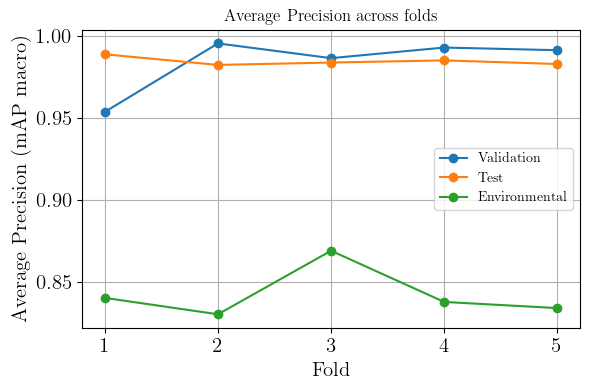

mAP val  : 0.9839802456916191 +/- 0.015457687061191536
mAP test : 0.9846013248581673 +/- 0.0023098136708965093
mAP env  : 0.8420633572423082 +/- 0.01381407713194245


In [ ]:
folds = np.arange(1, len(ap_scores_test) + 1)

fig_dir = f"history/{timestr}"
os.makedirs(fig_dir, exist_ok=True)

plt.figure(figsize=(6, 4))
plt.plot(folds, ap_scores_val, marker="o")
plt.plot(folds, ap_scores_test, marker="o")
plt.plot(folds, ap_scores_env, marker="o")
plt.xlabel("Fold")
plt.ylabel("Average Precision (mAP macro)")
plt.title("Average Precision across folds")
plt.legend(["Validation", "Test", "Environmental"])
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{fig_dir}/ap_across_folds.pdf", format="pdf")
plt.show()


summary_path = f"{fig_dir}/map_summary.txt"

with open(summary_path, "w") as f:
    f.write("Mean Average Precision (mAP) summary\n")
    f.write("=" * 40 + "\n\n")

    f.write(f"Validation set:\n")
    f.write(f"  mAP = {np.mean(ap_scores_val):.4f} ± {np.std(ap_scores_val):.4f}\n\n")
    print("mAP val  :", np.mean(ap_scores_val),  "+/-", np.std(ap_scores_val))

    f.write(f"Test set:\n")
    f.write(f"  mAP = {np.mean(ap_scores_test):.4f} ± {np.std(ap_scores_test):.4f}\n\n")
    print("mAP test :", np.mean(ap_scores_test), "+/-", np.std(ap_scores_test))

    f.write(f"Environmental set:\n")
    f.write(f"  mAP = {np.mean(ap_scores_env):.4f} ± {np.std(ap_scores_env):.4f}\n")
    print("mAP env  :", np.mean(ap_scores_env),  "+/-", np.std(ap_scores_env))


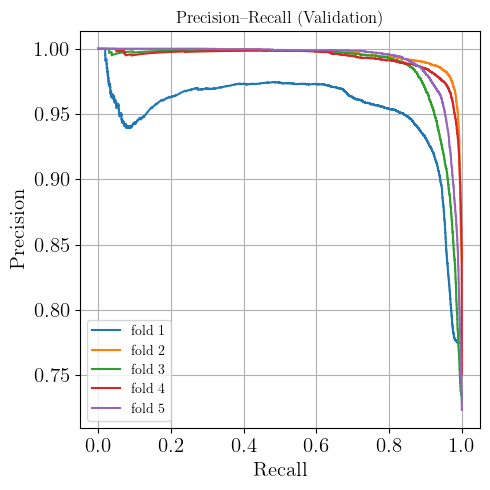

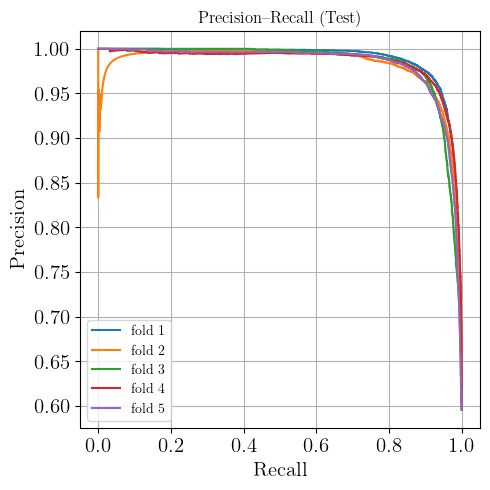

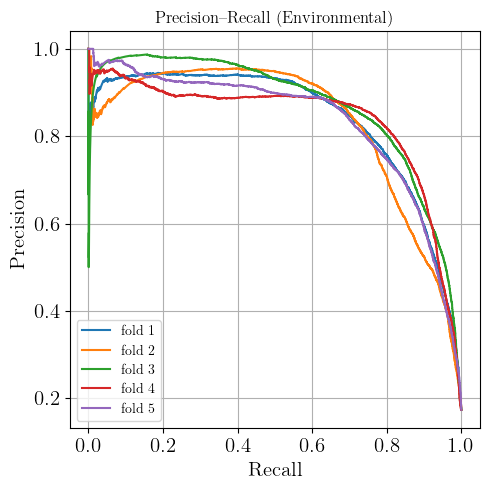

In [ ]:
def save_pr_curves(pr_curves, title, filename):
    plt.figure(figsize=(5, 5))
    for i, (p, r) in enumerate(pr_curves, start=1):
        plt.plot(r, p, label=f"fold {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename, format="pdf")
    plt.show()

save_pr_curves(
    pr_curves_val,
    "Precision–Recall (Validation)",
    f"{fig_dir}/pr_curve_validation.pdf"
)

save_pr_curves(
    pr_curves_test,
    "Precision–Recall (Test)",
    f"{fig_dir}/pr_curve_test.pdf"
)

save_pr_curves(
    pr_curves_env,
    "Precision–Recall (Environmental)",
    f"{fig_dir}/pr_curve_environmental.pdf"
)

In [ ]:
# Load model (Keras)

# path = "history/20260203-XXXXXX/merged_model.h5"  # Update with actual path
# model = tf.keras.models.load_model(path)

In [ ]:
# # # Test and evaluate the model (Keras)

# y_pred_test = model.predict(X_test)
# # y_pred_test = postprocess_output(y_pred_test)  # If needed

# y_pred_env = model.predict(X_env)
# # y_pred_env = postprocess_output(y_pred_env)  # If needed

# average_precision = average_precision_score(y_test, y_pred_test, average='macro')

In [ ]:
# Load metrics if desired

# event_metric = load_sed_metric(f'history/20251212-162657/Event-based-dataset.pk1')
# segment_metric = load_sed_metric(f'history/20251212-162657/Segment-based-dataset.pk1')

# print_metrics(event_metrics.results_class_wise_average_metrics(), "Event-based (Env set)")
# print_metrics(segment_metrics.results_class_wise_average_metrics(), "Segment-based (Env set)")
